<a href="https://colab.research.google.com/github/asp123-cyber/VACprojectweb/blob/main/Paper_K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving lcparam_full_long.txt to lcparam_full_long.txt


/tmp/ipython-input-4-2863317341.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('lcparam_full_long.txt', delim_whitespace=True, engine='python')
/tmp/ipython-input-4-2863317341.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(z, dL, dmL, fmt='.k', color='black',ecolor='green', elinewidth=1, capsize=3,label='Pantheon')


    #name     zcmb     zhel   dz        mb      dmb  x1  dx1  color  dcolor  \
0  03D1au  0.50309  0.50309  0.0  22.93445  0.12605   0    0      0       0   
1  03D1ax  0.49480  0.49480  0.0  22.88020  0.11765   0    0      0       0   
2  03D1co  0.67767  0.67767  0.0  24.03770  0.20560   0    0      0       0   
3  03D1ew  0.86650  0.86650  0.0  24.34685  0.17385   0    0      0       0   
4  03D1fq  0.79857  0.79857  0.0  24.36050  0.17435   0    0      0       0   

   3rdvar  d3rdvar  cov_m_s  cov_m_c  cov_s_c  set  ra  dec  biascor  
0       0        0        0        0        0    0   0    0      NaN  
1       0        0        0        0        0    0   0    0      NaN  
2       0        0        0        0        0    0   0    0      NaN  
3       0        0        0        0        0    0   0    0      NaN  
4       0        0        0        0        0    0   0    0      NaN  
Shape: (1048, 19)


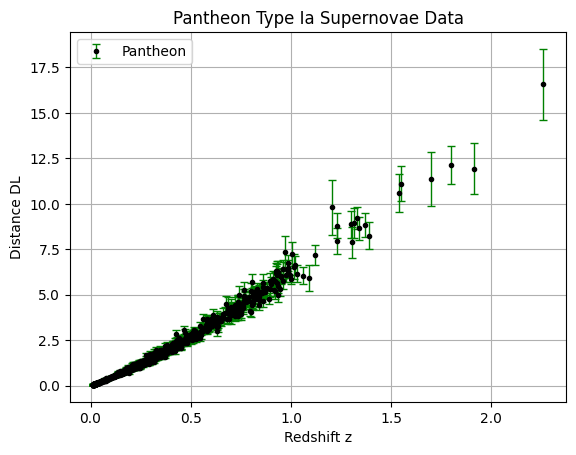

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your sample data (e.g., pasted into a CSV or TXT file)
df = pd.read_csv('lcparam_full_long.txt', delim_whitespace=True, engine='python')

# Show the first few rows
print(df.head())

# Check number of rows and columns
print("Shape:", df.shape)
# Extract z and mb (distance modulus)    # zcmb
z = df['zcmb'].values
mb = df['mb'].values
dmb = df['dmb'].values     # uncertainty in mb

# Fixed absolute magnitude from Pantheon
M_B = -19.220

# Compute mu = mb - M_B
mu = mb - M_B

# Compute luminosity distance (in Gpc)
dL = (10 ** ((mu -25) / 5))/1000
dmL=np.log(10)*(dL/5)*dmb
# Plot distance modulus vs redshift
plt.errorbar(z, dL, dmL, fmt='.k', color='black',ecolor='green', elinewidth=1, capsize=3,label='Pantheon')
plt.xlabel('Redshift z')
plt.ylabel('Distance DL')
plt.title('Pantheon Type Ia Supernovae Data')
plt.grid(True)
plt.legend()
plt.show()

Ashish(Gemeni)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import scipy.optimize as optimize
import time

# --- Start of Execution Timer ---
start_time = time.time()

# Load your sample data
try:
    df = pd.read_csv('lcparam_full_long.txt', sep=r'\s+', engine='python')
except FileNotFoundError:
    print("Error: 'lcparam_full_long.txt' not found.")
    exit()

# Extract data and convert to standard units
z = df['zcmb'].values
mb = df['mb'].values
dmb = df['dmb'].values
M_B = -19.220
mu = mb - M_B
# Luminosity Distance in Mpc
dL_data = 10 ** ((mu - 25) / 5)
# Propagated error in dL
dmL_data = np.log(10) * (dL_data / 5) * dmb

# --- Cosmological Model and Likelihood Functions (Refactored) ---

def iterations(n):
    """
    This function is now structured to work directly with physical parameters H0 and Om.
    """
    # The integrand now only needs the core cosmological parameters
    def H_integrand(z_, x, y, Ok, Ov):
        Or = 8.5e-5 # Radiation density
        H0=(x*y)**(1/4)
        Om=(y/x)**(1/2)
        On = 1 - Om - Ok - Ov # Dark energy component 'n'
        E_z_squared = Or * (1 + z_)**4 + Om * (1 + z_)**3 + Ok * (1 + z_)**2 + On * (1 + z_)**n + Ov
        if E_z_squared < 0: return np.inf
        return 1 / (H0 * np.sqrt(E_z_squared))

    # Theo  `retical DL now takes H0 and Om directly, no x or y
    def DL_theory_single(z, x, y, Ok, Ov):
        C_km_s = 299792.458 # Speed of light in km/s
        H0=(x*y)**(1/4)
        Om=(y/x)**(1/2)
        integral, err = quad(H_integrand, 0, z, args=(H0, Om, Ok, Ov))
        if np.isinf(integral): return np.inf

        # Calculate luminosity distance based on curvature
        comoving_dist = integral * C_km_s
        sqrt_abs_Ok = np.sqrt(abs(Ok)) * H0 / C_km_s

        if Ok > 1e-6: # Closed universe
            return (1 + z) * np.sin(H0*sqrt_abs_Ok * comoving_dist) / sqrt_abs_Ok
        elif Ok < -1e-6: # Open universe
            return (1 + z) * np.sinh(sqrt_abs_Ok * comoving_dist) / sqrt_abs_Ok
        else: # Flat universe
            return (1 + z) * comoving_dist

    # Vectorize for efficiency
    DL_theory_vec = np.vectorize(DL_theory_single, excluded=['x', 'y', 'Ok', 'Ov'])

    # The chi-squared calculation
    def chi2_calc(x, y, Ok, Ov):
        dL_model = DL_theory_vec(z=z, x=x, y=y, Ok=Ok, Ov=Ov)
        if np.any(np.isinf(dL_model)): return np.inf
        return np.sum(((dL_data - dL_model) / dmL_data)**2)

    # Function to be minimized (negative log-posterior)
    def neg_log_posterior(theta):
        x, y, Ov, Ok = theta
        yprior= -(y-1424.18)**2/(31.37**2)
        # Priors: Set physically motivated, stable boundaries
        if not (8000 < x < 22000 and 0 < Ov < 1 and -1 < Ok < 1):
            return np.inf
        return chi2_calc(x, y, Ok, Ov)+yprior

    # --- Run the Minimization ---
    # Initial guess is now in terms of physical parameters
    initial_guess = [16333, 1470, 0.7, 0.0]
    print("Starting the minimization process with physical parameters...")

    result = optimize.minimize(neg_log_posterior, initial_guess, method='Nelder-Mead',
                               options={'maxiter': 5000, 'adaptive': True, 'disp': True})

    if result.success:
        fitted_params = result.x
        print("\nMinimization successful!")
        print(f"Fitted x: {fitted_params[0]:.4f} km/s/Mpc")
        print(f"Fitted y: {fitted_params[1]:.4f}")
        print(f"Fitted Ov: {fitted_params[2]:.4f}")
        print(f"Fitted Ok: {fitted_params[3]:.4f}")
        print(f"Sum of densities (Om+Ov+Ok): {np.sum(fitted_params[1:]):.4f}")
    else:
        print("\nMinimization failed.")
        raise ValueError(result.message)

# Run for a standard Lambda-CDM model where n=0
iterations(0)

# --- End of Execution Timer ---
end_time = time.time()
print(f"\nTotal execution time: {end_time - start_time:.2f} seconds")

Starting the minimization process with physical parameters...
Optimization terminated successfully.
         Current function value: 59614778.896014
         Iterations: 730
         Function evaluations: 1357

Minimization successful!
Fitted x: 22000.0000 km/s/Mpc
Fitted y: 5596.0609
Fitted Ov: 1.0000
Fitted Ok: 0.0308
Sum of densities (Om+Ov+Ok): 5597.0917

Total execution time: 102.39 seconds


HIMANSHU'S CODE MODIFIED

Enter value of n: 1


/usr/local/lib/python3.11/dist-packages/scipy/optimize/_optimize.py:2502: RuntimeWarning: invalid value encountered in scalar multiply
  tmp2 = (x - v) * (fx - fw)



--- Best-Fit Results ---
x        = 21999.9920
y        = 1423.9436
H0       = 74.8133 km/s/Mpc
Omega_m  = 0.2544
Omega_L  = 0.6255
Omega_k  = 0.0115
Omega_n  = 0.1085
chi2     = 1025.80
reduced chi2 = 0.9826


/tmp/ipython-input-7-1651577442.py:96: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(z, dL_data / 1000, yerr=dmL_data / 1000, fmt='.k', color='black',ecolor='green', elinewidth=1, capsize=3, alpha=0.6)
/tmp/ipython-input-7-1651577442.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


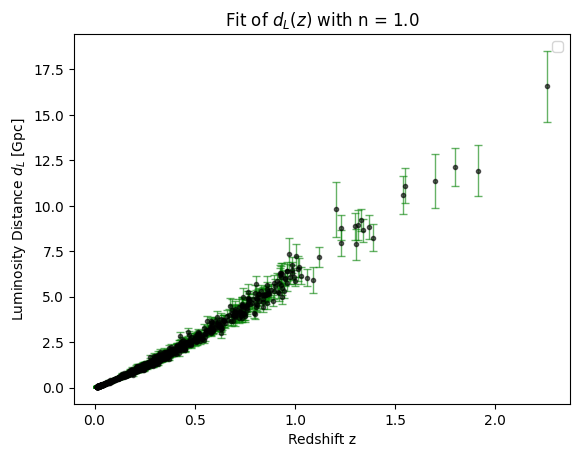

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize
import time

# --- Load Data ---
df = pd.read_csv('lcparam_full_long.txt', sep=r'\s+', engine='python')
z = df['zcmb'].values
mb = df['mb'].values
dmu = df['dmb'].values  # Assumed to be the correct mu uncertainty column
M_B = -19.220
mu = mb - M_B

# Luminosity distance and error in Mpc
dL_data = 10 ** ((mu - 25) / 5)
dmL_data = np.log(10) * dL_data * dmu / 5

# --- Define Constants ---
C = 299792.458  # km/s
Or = 8.5e-5  # radiation density

# --- Model Functions ---
def H_integrand(z_, x, y, Ov, Ok, n):
    H0 = (x * y)**0.25
    Om = np.sqrt(y / x)
    On = 1 - Om - Ok - Ov - Or
    Ez2 = Or * (1 + z_)**4 + Om * (1 + z_)**3 + Ok * (1 + z_)**2 + On * (1 + z_)**n + Ov
    if Ez2 <= 0:
        return np.inf
    return 1 / (H0 * np.sqrt(Ez2))

def DL_theory_single(z, x, y, Ov, Ok, n):
    H0 = (x * y)**0.25
    try:
        integral, _ = quad(H_integrand, 0, z, args=(x, y, Ov, Ok, n), limit=200)
    except:
        return np.inf
    sqrtOk = np.sqrt(abs(Ok))
    if Ok < 0:
        return C * (1 + z) * np.sinh(H0 * sqrtOk * integral) / (H0 * sqrtOk)
    elif Ok > 0:
        return C * (1 + z) * np.sin(H0 * sqrtOk * integral) / (H0 * sqrtOk)
    else:
        return C * (1 + z) * integral

DL_theory_vec = np.vectorize(DL_theory_single, excluded=['x', 'y', 'Ov', 'Ok', 'n'])

# --- Chi-Squared ---
def log_posterior(theta, n):
    x, y, Ov, Ok = theta
    if 8000 <= x <= 22000 and -1 <= Ok <= 1 and 0 <= Ov <= 1:
        xprior, Okprior, Ovprior=0,0,0
    else:
        xprior, Okprior, Ovprior=-np.inf,-np.inf,-np.inf
    """H0 = (x * y)**0.25
    Om = np.sqrt(y / x)
    On = 1 - Om - Ok - Ov - Or
    if On < -1 or On >1:
        return -np.inf"""
    yprior = -((y - 1424.18)**2 / (2 * 31.37**2))
    priors=xprior+Okprior+Ovprior+yprior
    dL_model = DL_theory_vec(z=z, x=x, y=y, Ok=Ok, Ov=Ov, n=n)
    if np.any(np.isnan(dL_model)) or np.any(np.isinf(dL_model)):
        return -np.inf
    chi_sq = np.sum(((dL_data - dL_model) / dmL_data)**2)
    return -0.5*chi_sq + priors
def chi2(theta, n):
    x, y, Ov, Ok = theta
    return -2*log_posterior(theta, n)
# --- Minimization ---
n_value = float(input("Enter value of n: "))
initial_guess = [19357, 1403.8, 0.594, -0.053]  # from paper (for n=1)
result = minimize(chi2, initial_guess, args=(n_value,), method='Powell')

x, y, Ov, Ok = result.x
H0 = (x  * y)**0.25
Om = np.sqrt(y / x)
On = 1 - Om - Ok - Ov - Or

print("\n--- Best-Fit Results ---")
print(f"x        = {x:.4f}")
print(f"y        = {y:.4f}")
print(f"H0       = {H0:.4f} km/s/Mpc")
print(f"Omega_m  = {Om:.4f}")
print(f"Omega_L  = {Ov:.4f}")
print(f"Omega_k  = {Ok:.4f}")
print(f"Omega_n  = {On:.4f}")
chi2_val = chi2(result.x, n_value)
print(f"chi2     = {chi2_val:.2f}")
print(f"reduced chi2 = {chi2_val / (len(z) - 4):.4f}")

# --- Plot Fit ---
#dL_model = DL_theory_vec(z=z, x=x, y=y, Ov=Ov, Ok=Ok, n=n_value)
plt.errorbar(z, dL_data / 1000, yerr=dmL_data / 1000, fmt='.k', color='black',ecolor='green', elinewidth=1, capsize=3, alpha=0.6)
#plt.plot(z, dL_model / 1000, 'r-', label="Best-Fit Model")
plt.xlabel("Redshift z")
plt.ylabel("Luminosity Distance $d_L$ [Gpc]")
plt.legend()
#plt.grid()
plt.title("Fit of $d_L(z)$ with n = {:.1f}".format(n_value))
plt.show()

In [8]:
no_of_steps_per_walker= 1000
#burn_in_steps=500
ndim = 4
nwalkers = 12  # or at most 2×ndim

# result.x should be the paper's best-fit: [x, y, Ov, Ok]
initial_pos_of_walker = [result['x'] + 1e-3*np.random.randn(ndim) for i in range(nwalkers)]
print(initial_pos_of_walker)

[array([2.19999916e+04, 1.42394407e+03, 6.25292264e-01, 1.10376948e-02]), array([2.19999909e+04, 1.42394382e+03, 6.24479194e-01, 1.22256610e-02]), array([2.19999926e+04, 1.42394180e+03, 6.26780890e-01, 1.27217306e-02]), array([2.19999913e+04, 1.42394296e+03, 6.25808094e-01, 1.15958640e-02]), array([2.19999899e+04, 1.42394330e+03, 6.23136098e-01, 1.29872787e-02]), array([2.19999921e+04, 1.42394553e+03, 6.25186687e-01, 1.30585483e-02]), array([2.19999927e+04, 1.42394152e+03, 6.24980244e-01, 1.25053673e-02]), array([2.19999918e+04, 1.42394261e+03, 6.25527164e-01, 8.96502658e-03]), array([2.19999921e+04, 1.42394305e+03, 6.24752294e-01, 1.27268921e-02]), array([2.19999929e+04, 1.42394431e+03, 6.23305469e-01, 1.21099715e-02]), array([2.19999920e+04, 1.42394385e+03, 6.25071776e-01, 1.09495790e-02]), array([2.19999919e+04, 1.42394180e+03, 6.24486608e-01, 1.00170982e-02])]


In [9]:
!pip install -U emcee
!pip install -U corner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.6 MB/s eta 0:00:00


In [ ]:
import emcee
n=1
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(n_value,))
sampler.run_mcmc(initial_pos_of_walker, no_of_steps_per_walker, rstate0=np.random.get_state(),progress=True);

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 1000/1000 [20:52<00:00,  1.25s/it]


In [ ]:
burn_in_steps=100
log_post_bestfit = log_posterior(initial_guess, n_value)
log_post_emcee_max = np.max(sampler.get_log_prob(discard=burn_in_steps, flat=True))
print("Best-fit log posterior:", log_post_bestfit)
print("Max emcee log posterior:", log_post_emcee_max)

Best-fit log posterior: -690.9282473367169
Max emcee log posterior: -511.00518496954476


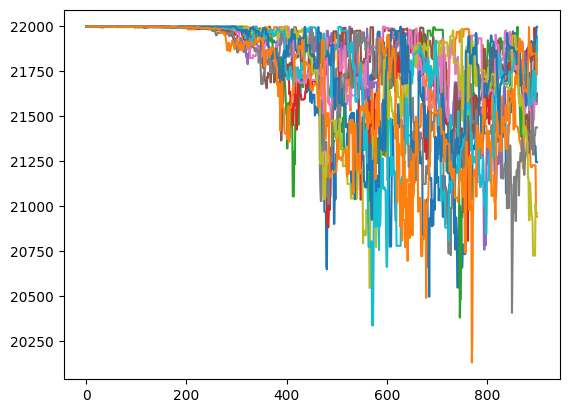

In [ ]:
import matplotlib.pyplot as plt
for i in range(0,nwalkers):
  a=sampler.chain[i,burn_in_steps:,0]
  l=len(a)
  n= list(range(l))
  plt.plot(n,a)

plt.show()

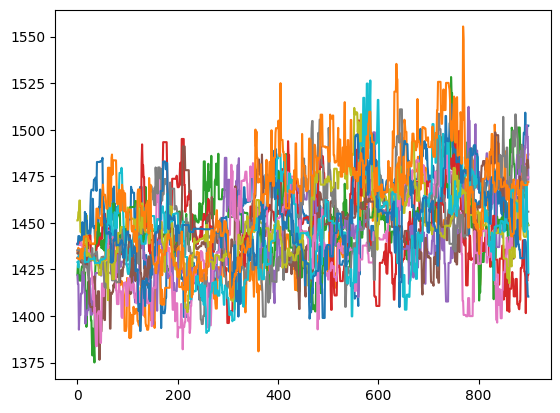

In [ ]:
#Plotting chains for value of 'Omega_lambda'
for i in range(0,nwalkers):
  b=sampler.chain[i,burn_in_steps:,1]
  l=len(b)
  n= list(range(l))
  plt.plot(n,b)

plt.show()

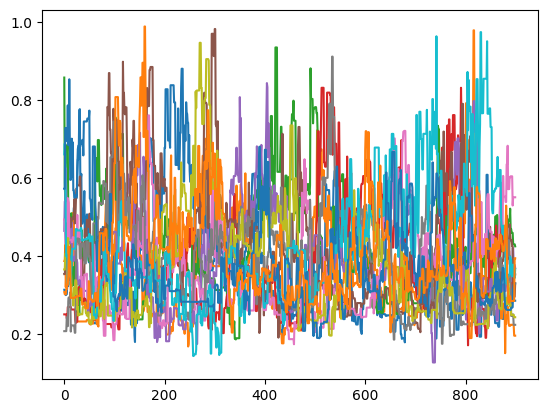

In [ ]:
for i in range(0,nwalkers):
  c=sampler.chain[i,burn_in_steps:,2]
  l=len(c)
  n= list(range(l))
  plt.plot(n,c)

plt.show()

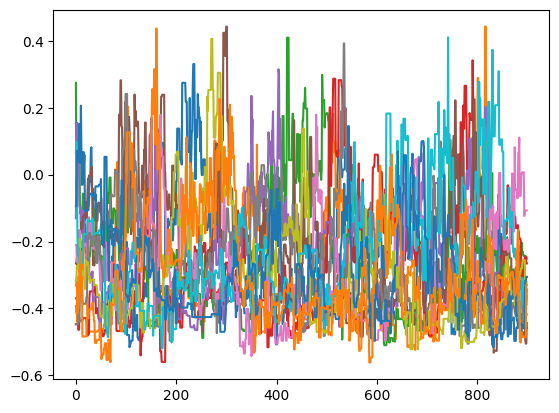

In [ ]:
for i in range(0,nwalkers):
  d=sampler.chain[i,burn_in_steps:,3]
  l=len(d)
  n= list(range(l))
  plt.plot(n,d)

plt.show()

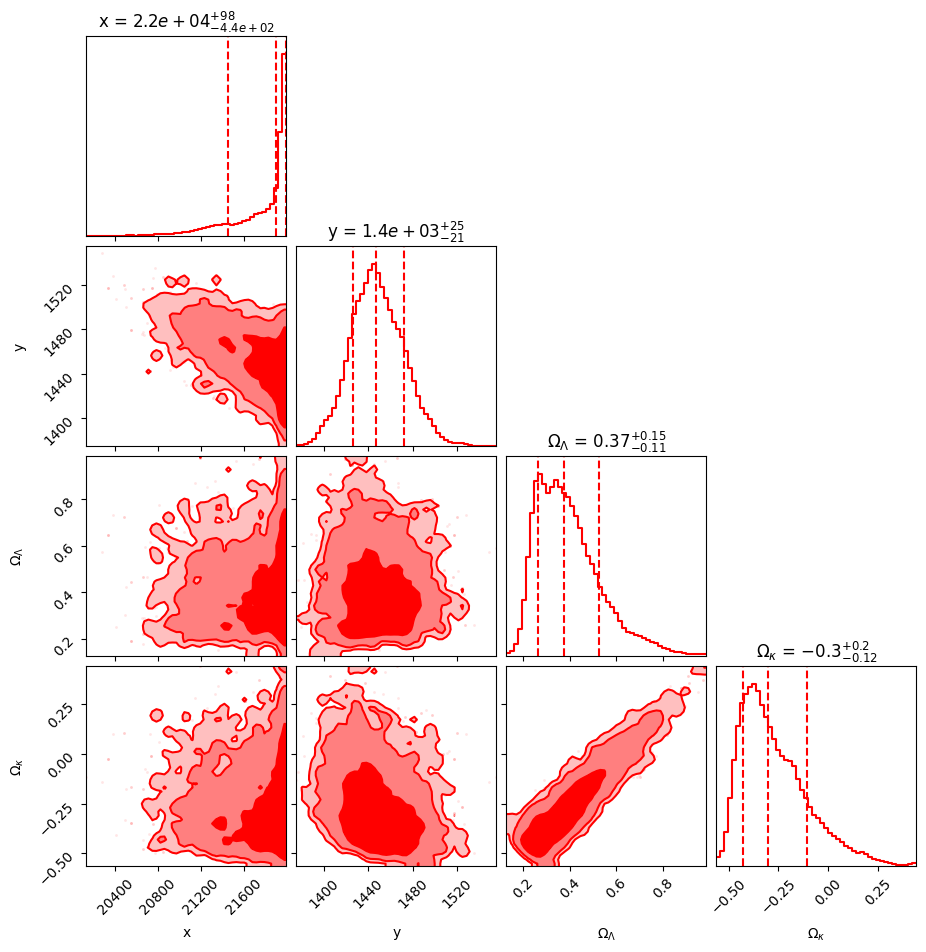

In [ ]:
import corner
samples = sampler.chain[:, burn_in_steps:, :].reshape((-1, ndim))
fig = corner.corner(samples,bins=50,labels=["x", "y","$\Omega_{\Lambda}$","$\Omega_{\kappa}$"],
                    color="red",
                    quantiles=[0.16, 0.5, 0.84],                    #68% Confidence Error in Histogram
                    plot_contours=True,
                    fill_contours=True,
                    levels=(0.68,0.95,0.99),                        #Confidence Levels
                    plot_datapoints=True,
                    smooth=True, smooth1d=True,
                    title_fmt=".2g",
                    show_titles=True,
                    divergences=True)

plt.show()

In [ ]:
samples = sampler.get_chain(discard=burn_in_steps, flat=True)
x_vals, y_vals, Ok_vals, Ov_vals = samples.T
H0_vals = (x_vals * y_vals) ** 0.25
Om_vals = np.sqrt(y_vals / x_vals)
Or = 8.5e-5
On_vals = 1 - Om_vals - Ok_vals - Ov_vals - Or
def median_and_err(x):
    q16, q50, q84 = np.percentile(x, [16, 50, 84])
    return q50, q84 - q50, q50 - q16
H0_m, H0_p, H0_m_err = median_and_err(H0_vals)
Om_m, Om_p, Om_m_err = median_and_err(Om_vals)
On_m, On_p, On_m_err = median_and_err(On_vals)
Ok_m, Ok_p, Ok_m_err = median_and_err(Ok_vals)
Ov_m, Ov_p, Ov_m_err = median_and_err(Ov_vals)
x_m, x_p, x_m_err = median_and_err(x_vals)
y_m, y_p, y_m_err = median_and_err(y_vals)
print(f"H0 = {H0_m:.2f} +{H0_p:.2f} -{H0_m_err:.2f}")
print(f"Ωm = {Om_m:.3f} +{Om_p:.3f} -{Om_m_err:.3f}")
print(f"Ωn = {On_m:.3f} +{On_p:.3f} -{On_m_err:.3f}")

H0 = 74.93 +0.24 -0.24
Ωm = 0.257 +0.004 -0.002
Ωn = 0.671 +0.231 -0.350


In [ ]:
import pandas as pd
dl=DL_theory_single
DL_theory_vec = np.vectorize(DL_theory_single, excluded=['x', 'y', 'Ov', 'Ok', 'n'])
dL_model = np.array(DL_theory_vec(z=z, x=x_m, y=y_m, Ok=Ok_m, Ov=Ov_m, n=1.0))
diff=abs(dL_model-dL_data)
dict1=pd.DataFrame({"Z":z,"DL_theory": dL_model, "DL_obs": dL_data, "Difference": diff, "error in DL":dmL_data })
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
print(dict1)

            Z     DL_theory        DL_obs   Difference  error in DL
0     0.50309   2428.638148   2697.056224   268.418075   156.559179
1     0.49480   2382.412086   2630.510260   248.098174   142.520591
2     0.67767   3444.979334   4482.703353  1037.724019   424.432659
3     0.86650   4631.015899   5168.565210   537.549311   413.799898
4     0.79857   4194.451382   5201.157438  1006.706056   417.606871
5     0.37144   1717.505948   2002.488359   284.982411   114.811406
6     0.35582   1636.463985   1802.312107   165.848122   104.952918
7     0.28360   1271.313185   1336.072423    64.759237    63.251204
8     0.46640   2225.499508   3070.930586   845.431078   224.436047
9     0.94688   5161.374653   5324.882145   163.507491   402.651051
10    0.69315   3538.920607   4011.344856   472.424249   451.570670
11    0.89693   4830.066281   5303.346461   473.280180   406.517723
12    0.78904   4134.079314   4872.591463   738.512150   259.957123
13    0.59027   2926.101118   3243.993684   317.

WITHOUT MINIMIZNG CHI2

Enter value of n: 1


/tmp/ipython-input-13-1425777948.py:77: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(z, dL_data / 1000, yerr=dmL_data / 1000, fmt='.k', color='black',ecolor='green', elinewidth=1, capsize=3, alpha=0.6)
/tmp/ipython-input-13-1425777948.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


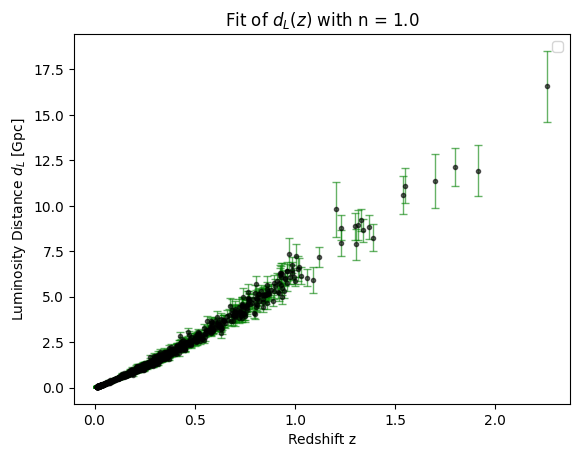

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize
import time

# --- Load Data ---
df = pd.read_csv('lcparam_full_long.txt', sep=r'\s+', engine='python')
z = df['zcmb'].values
mb = df['mb'].values
dmu = df['dmb'].values  # Assumed to be the correct mu uncertainty column
M_B = -19.220
mu = mb - M_B

# Luminosity distance and error in Mpc
dL_data = 10 ** ((mu - 25) / 5)
dmL_data = np.log(10) * dL_data * dmu / 5

# --- Define Constants ---
C = 299792.458  # km/s
Or = 8.5e-5  # radiation density

# --- Model Functions ---
def H_integrand(z_, x, y, Ov, Ok, n):
    H0 = (x * y)**0.25
    Om = np.sqrt(y / x)
    On = 1 - Om - Ok - Ov - Or
    Ez2 = Or * (1 + z_)**4 + Om * (1 + z_)**3 + Ok * (1 + z_)**2 + On * (1 + z_)**n + Ov
    if Ez2 <= 0:
        return np.inf
    return 1 / (H0 * np.sqrt(Ez2))

def DL_theory_single(z, x, y, Ov, Ok, n):
    H0 = (x * y)**0.25
    try:
        integral, _ = quad(H_integrand, 0, z, args=(x, y, Ov, Ok, n), limit=200)
    except:
        return np.inf
    sqrtOk = np.sqrt(abs(Ok))
    if Ok > 0:
        return C * (1 + z) * np.sinh(H0 * sqrtOk * integral) / (H0 * sqrtOk)
    elif Ok < 0:
        return C * (1 + z) * np.sin(H0 * sqrtOk * integral) / (H0 * sqrtOk)
    else:
        return C * (1 + z) * integral

DL_theory_vec = np.vectorize(DL_theory_single, excluded=['x', 'y', 'Ov', 'Ok', 'n'])

# --- Chi-Squared ---
def log_posterior(theta, n):
    x, y, Ov, Ok = theta
    if 8000 <= x <= 25000 and -1 <= Ok <= 1 and 0 <= Ov <= 1:
        xprior, Okprior, Ovprior=0,0,0
    else:
        xprior, Okprior, Ovprior=-np.inf,-np.inf,-np.inf
    H0 = (x * y)**0.25
    Om = np.sqrt(y / x)
    On = 1 - Om - Ok - Ov - Or
    if On < -1 or On >1:
        return -np.inf
    yprior = -((y - 1424.18)**2 / (2 * 31.37**2))
    priors=xprior+Okprior+Ovprior+yprior
    dL_model = DL_theory_vec(z=z, x=x, y=y, Ok=Ok, Ov=Ov, n=n)
    if np.any(np.isnan(dL_model)) or np.any(np.isinf(dL_model)):
        return -np.inf
    chi_sq = np.sum(((dL_data - dL_model) / dmL_data)**2)
    return -0.5*chi_sq + priors
def chi2(theta, n):
    x, y, Ov, Ok = theta
    return -2*log_posterior(theta, n)
# --- Minimization ---
n_value = float(input("Enter value of n: "))
initial_guess = [19357, 1403.8, 0.594, -0.053]  # from paper (for n=1)
# --- Plot Fit ---
#dL_model = DL_theory_vec(z=z, x=x, y=y, Ov=Ov, Ok=Ok, n=n_value)
plt.errorbar(z, dL_data / 1000, yerr=dmL_data / 1000, fmt='.k', color='black',ecolor='green', elinewidth=1, capsize=3, alpha=0.6)
#plt.plot(z, dL_model / 1000, 'r-', label="Best-Fit Model")
plt.xlabel("Redshift z")
plt.ylabel("Luminosity Distance $d_L$ [Gpc]")
plt.legend()
#plt.grid()
plt.title("Fit of $d_L(z)$ with n = {:.1f}".format(n_value))
plt.show()

In [14]:
ndimension=4
no_of_walkers=20
no_of_steps_per_walker= 12000
#burn_in_steps=500

initial_pos_of_walker = [initial_guess + 1e-3*np.random.randn(ndimension) for i in range(no_of_walkers)]
print(initial_pos_of_walker)

[array([ 1.93570013e+04,  1.40380091e+03,  5.93667223e-01, -5.38353269e-02]), array([ 1.93570014e+04,  1.40379945e+03,  5.95540687e-01, -5.30167035e-02]), array([ 1.93570000e+04,  1.40379927e+03,  5.93761306e-01, -5.31604356e-02]), array([ 1.93570003e+04,  1.40380058e+03,  5.93121657e-01, -5.21403845e-02]), array([ 1.93569992e+04,  1.40379967e+03,  5.95920614e-01, -5.26014020e-02]), array([ 1.93570005e+04,  1.40379952e+03,  5.94737230e-01, -5.31231770e-02]), array([ 1.93569996e+04,  1.40379940e+03,  5.95324257e-01, -5.34793470e-02]), array([ 1.93569990e+04,  1.40380068e+03,  5.93992598e-01, -5.28209190e-02]), array([ 1.93569990e+04,  1.40380001e+03,  5.93456920e-01, -5.30576856e-02]), array([ 1.93569997e+04,  1.40380101e+03,  5.93732463e-01, -5.28208479e-02]), array([ 1.93570015e+04,  1.40380073e+03,  5.95117179e-01, -5.47495097e-02]), array([ 1.93570007e+04,  1.40380017e+03,  5.94044596e-01, -5.36651451e-02]), array([ 1.93570005e+04,  1.40379941e+03,  5.94477953e-01, -5.10495572e-02])

In [15]:
import emcee
n=1
sampler = emcee.EnsembleSampler(no_of_walkers, ndimension, log_posterior,args=(n_value,), a=2)
sampler.run_mcmc(initial_pos_of_walker, no_of_steps_per_walker, rstate0=np.random.get_state(),progress=True);

  4%|▎         | 420/12000 [09:04<3:51:06,  1.20s/it]Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-13-1425777948.py", line 64, in log_posterior
    dL_model = DL_theory_vec(z=z, x=x, y=y, Ok=Ok, Ov=Ov, n=n)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py", line 2397, in __call__
    return self._call_as_normal(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py", line 2390, in _call_as_normal
    return self._vectorize_call(func=func, args=vargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py", line 2480, in _vec

emcee: Exception while calling your likelihood function:
  params: [ 2.23867320e+04  1.49840207e+03  4.32852634e-01 -3.49428693e-01]
  args: (1.0,)
  kwargs: {}
  exception:


KeyboardInterrupt: 

In [ ]:
burn_in_steps=5000
log_post_bestfit = log_posterior(initial_guess, n_value)
log_post_emcee_max = np.max(sampler.get_log_prob(discard=burn_in_steps, flat=True))
print("Best-fit log posterior:", log_post_bestfit)
print("Max emcee log posterior:", log_post_emcee_max)

Best-fit log posterior: -690.9282473367169
Max emcee log posterior: -510.8778430603813


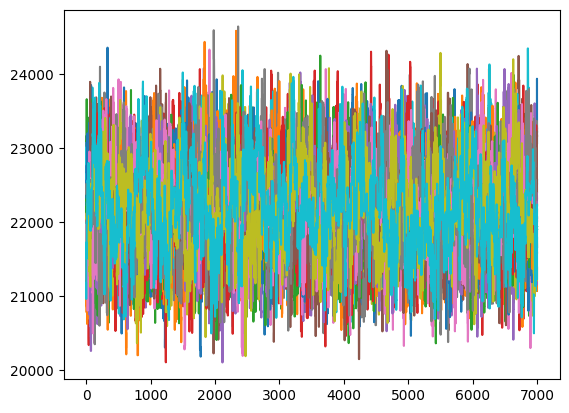

In [ ]:
import matplotlib.pyplot as plt
for i in range(0,no_of_walkers):
  a=sampler.chain[i,burn_in_steps:,0]
  l=len(a)
  n= list(range(l))
  plt.plot(n,a)

plt.show()

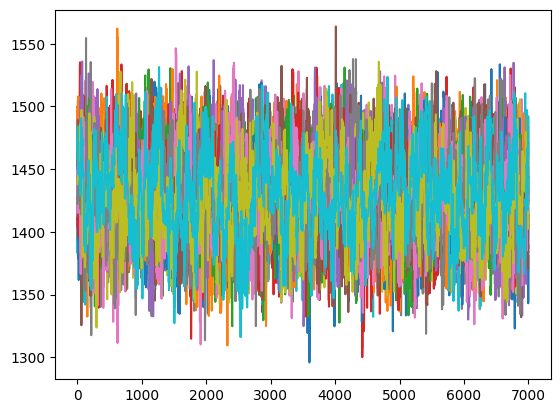

In [ ]:
#Plotting chains for value of 'Omega_lambda'
for i in range(0,no_of_walkers):
  b=sampler.chain[i,burn_in_steps:,1]
  l=len(b)
  n= list(range(l))
  plt.plot(n,b)

plt.show()

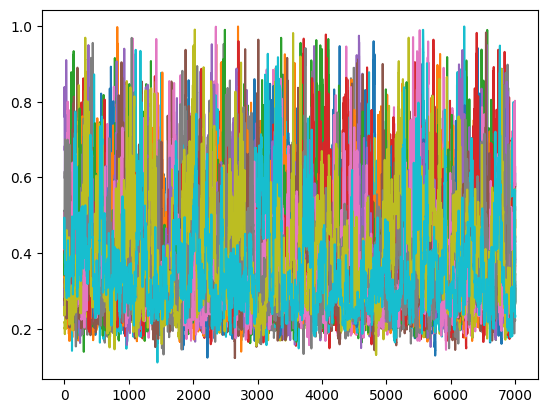

In [ ]:
for i in range(0,no_of_walkers):
  c=sampler.chain[i,burn_in_steps:,2]
  l=len(c)
  n= list(range(l))
  plt.plot(n,c)

plt.show()

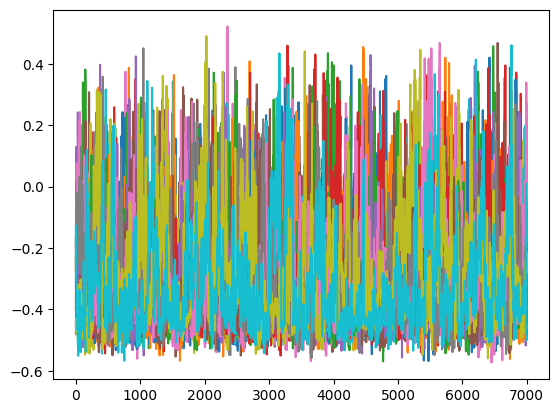

In [ ]:
for i in range(0,no_of_walkers):
  d=sampler.chain[i,burn_in_steps:,3]
  l=len(d)
  n= list(range(l))
  plt.plot(n,d)

plt.show()

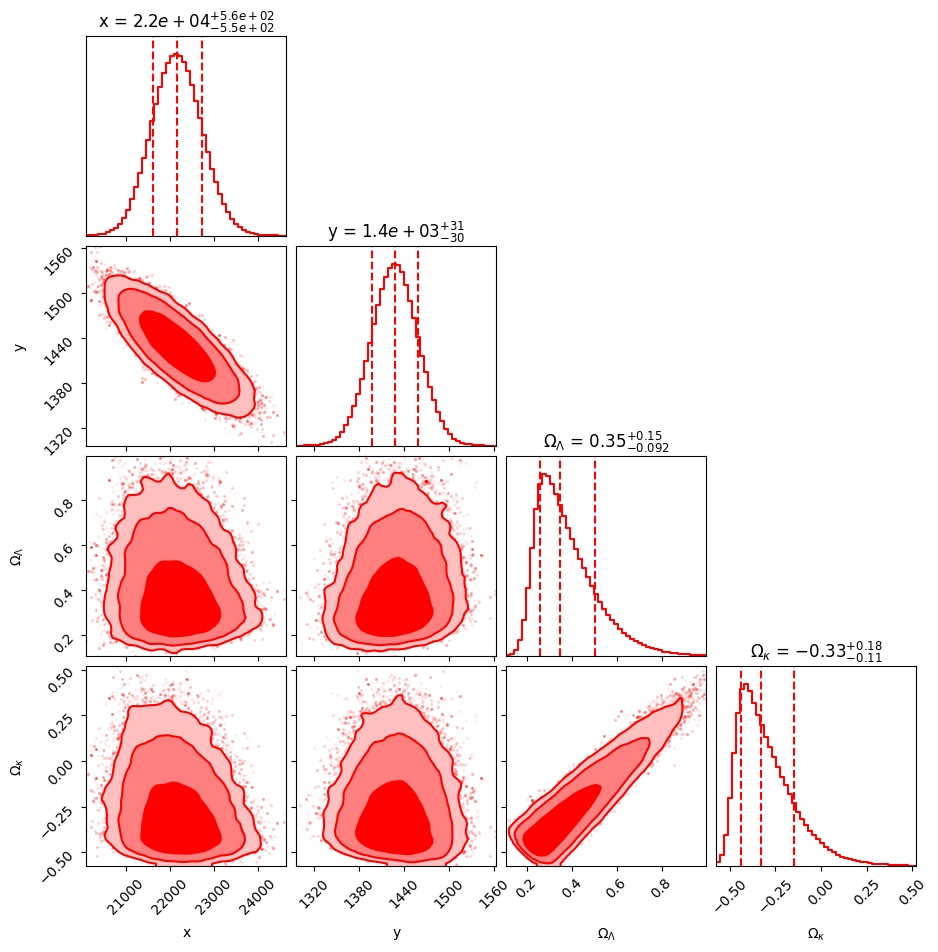

In [ ]:
import corner
samples = sampler.chain[:, burn_in_steps:, :].reshape((-1, ndimension))
fig = corner.corner(samples,bins=50,labels=["x", "y","$\Omega_{\Lambda}$","$\Omega_{\kappa}$"],
                    color="red",
                    quantiles=[0.16, 0.5, 0.84],                    #68% Confidence Error in Histogram
                    plot_contours=True,
                    fill_contours=True,
                    levels=(0.68,0.95,0.99),                        #Confidence Levels
                    plot_datapoints=True,
                    smooth=True, smooth1d=True,
                    title_fmt=".2g",
                    show_titles=True,
                    divergences=True)

plt.show()

In [ ]:
samples = sampler.get_chain(discard=burn_in_steps, flat=True)
x_vals, y_vals, Ok_vals, Ov_vals = samples.T
H0_vals = (x_vals * y_vals) ** 0.25
Om_vals = np.sqrt(y_vals / x_vals)
Or = 8.5e-5
On_vals = 1 - Om_vals - Ok_vals - Ov_vals - Or
def median_and_err(x):
    q16, q50, q84 = np.percentile(x, [16, 50, 84])
    return q50, q84 - q50, q50 - q16
H0_m, H0_p, H0_m_err = median_and_err(H0_vals)
Om_m, Om_p, Om_m_err = median_and_err(Om_vals)
On_m, On_p, On_m_err = median_and_err(On_vals)
Ok_m, Ok_p, Ok_m_err = median_and_err(Ok_vals)
Ov_m, Ov_p, Ov_m_err = median_and_err(Ov_vals)
x_m, x_p, x_m_err = median_and_err(x_vals)
y_m, y_p, y_m_err = median_and_err(y_vals)
print(f"H0 = {H0_m:.2f} +{H0_p:.2f} -{H0_m_err:.2f}")
print(f"Ωm = {Om_m:.3f} +{Om_p:.3f} -{Om_m_err:.3f}")
print(f"Ωn = {On_m:.3f} +{On_p:.3f} -{On_m_err:.3f}")

H0 = 75.01 +0.27 -0.27
Ωm = 0.254 +0.006 -0.006
Ωn = 0.729 +0.194 -0.336


In [ ]:
import pandas as pd
dl=DL_theory_single
DL_theory_vec = np.vectorize(DL_theory_single, excluded=['x', 'y', 'Ov', 'Ok', 'n'])
dL_model = np.array(DL_theory_vec(z=z, x=x_m, y=y_m, Ok=Ok_m, Ov=Ov_m, n=1.0))
diff=abs(dL_model-dL_data)
dict1=pd.DataFrame({"Z":z,"DL_theory": dL_model, "DL_obs": dL_data, "Difference": diff, "error in DL":dmL_data })
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
print(dict1)

            Z     DL_theory        DL_obs   Difference  error in DL
0     0.50309   2433.833947   2697.056224   263.222277   156.559179
1     0.49480   2387.509037   2630.510260   243.001223   142.520591
2     0.67767   3452.234280   4482.703353  1030.469073   424.432659
3     0.86650   4640.353739   5168.565210   528.211471   413.799898
4     0.79857   4203.065185   5201.157438   998.092253   417.606871
5     0.37144   1721.143890   2002.488359   281.344469   114.811406
6     0.35582   1639.920515   1802.312107   162.391592   104.952918
7     0.28360   1273.948828   1336.072423    62.123594    63.251204
8     0.46640   2230.258082   3070.930586   840.672505   224.436047
9     0.94688   5171.523824   5324.882145   153.358320   402.651051
10    0.69315   3546.353706   4011.344856   464.991150   451.570670
11    0.89693   4839.717431   5303.346461   463.629030   406.517723
12    0.78904   4142.589031   4872.591463   730.002432   259.957123
13    0.59027   2932.333633   3243.993684   311.